<img src="logo_UNSAM.jpg" align="right" width="150">

#### Análisis y Procesamiento de Señales

# *TS5 - Estimacion espectral: Ancho de banda de señales reales*

### *Autora: Catalina Gonzalez Araujo*

### *Docentes: Mariano Llamedo Soria, David Ezequiel Benoit, Francisco Hernan Ledesma.*

# <u>**Resumen**</u>

En el presente trabajo se buscó estimar la densidad espectral de potencia (*PSD*) de distintos tipos de señales: 

- Electrocardiograma (*ECG*)
- Pletismografia (*PPG*)
- Audio

Esto se hizo mediante distintos estimadores vistos en clase, como el método de *Welch* o el método de *Blackman-Tukey*. Se calculó la varianza en cada caso, de manera tal que se puedo analizar el comportamiento y la eficacia de ambos métodos. 

Por último, se realizó una estimación del ancho de banda de cada señal, y se mostraron los resultados en una tabla. 

# <u>**Introducción teórica**</u>
## Métodos de estimación espectral

En la práctica, el cálculo de la densidad espectral de potencia (PSD) es restringido, debido a que se cuenta con una cantidad de muestras y realizaciones limitadas del proceso aleatorio y generalmente se desconoce la función de probabilidad. Por ello, se utilizan diversos métodos de estimación espectral, que se detallan a continuación.

### Periodograma

Se define a $x[n]$ como un proceso aleatorio de longitud infinita, con media 0 y WSS (wide-sense stationary), cuya autocorrelación $r_{xx}[l]$ es absolutamente sumable.
$$
\sum_{l=-\infty}^{\infty} |r_{xx}[l]| < \infty
$$

La densidad espectral de potencia (PSD) de $x[n]$, $S_{xx}(\omega)$, se define mediante la DTFT de la función de autocorrelación.

$$
S_{xx}(\omega) \triangleq \mathcal{F}\{r_{xx}[l]\} = \sum_{l=-\infty}^{\infty} r_{xx}[l]e^{-j\omega l} \tag{14.6}
$$
El periodograma es un estimador de la densidad espectral de potencia basado en N mediciones sampleadas de x[n]. Se define mediante la siguiente ecuación:

$$
\hat{S}_{xx}(\omega,N)= \frac{1}{N} \mathcal{F}\{x[n]\} \cdot \mathcal{F}\{x[n-L]\} = \frac{1}{N} X_N(\omega) X_N^*(\omega) = \frac{1}{N} |X_N(\omega)|^2
$$

$$
= \left| \frac{1}{N} \sum_{n=0}^{N-1} x[n]e^{-j\omega n} \right|^2 \tag{14.15}
$$

Es un estimador con una alta varianza, por lo que se usan variantes mejoradas. 

### Método de Bartlet

El objetivo del método de Bartlett es hallar un estimador insesgado y consistente. Se fundamenta en la idea de que si se promedian M mediciones incorreladas de una variable aleatoria para formar la media muestral, la varianza de esta media disminuye en proporción a M.

Prácticamente, este método divide a la señal en bloques no solapados, calcula el espectro de cada uno y luego promedia los resultados. Reduce la varianza de la estimación a costa de una menor resolución espectral. Si se mejora la varianza k veces, se empeora la resolución espectral k veces. 

Su definición matemática es:

$$ P_B(\omega, L, M) \triangleq \frac{1}{M} \sum_{m=0}^{M-1} \left( \frac{1}{L} \sum_{n=0}^{N-1} x[n + mL] e^{-j\omega n} \right)^2  = \frac{1}{N} \sum_{m=0}^{M-1} \left( \sum_{n=0}^{N-1} x[n + mL] e^{-j\omega n}  \right)^2 $$ 

El valor esperado del periodograma promediado $P_B(ω;L;M)$ es el mismo que el del periodograma de un solo bloque (también es asintóticamente insesgado cuando L tiende a $\infty$)

$$
E (P_B(ω;L;M)) = E(\hat S_{xx} (ω;L))
$$

Si cada bloque es incorrelado y de igual varianza, entonces la varianza de la suma de M periodogramas es 1/M veces la varianza del periodograma de un bloque. Es decir, la varianza del estimador tiende a cero cuando M tiende a $\infty$

$$
var(P_B(ω;L;M))= \frac {1}{M}var(\hat S_{xx}(ω;L))
$$

### Método de Welch

Es equivalente a hacer el periodograma modificado promediado, pero se divide la secuencia de datos $x[n]$ en M tramos de longitud L que se solapan en D puntos. En cada tramo, los datos se multiplican por una ventana y se calculan y promedian los periodogramas para formar el de Welch. Es decir, se basa en el método de Bartlett, pero los bloques se encuentran solapados y agrega ventaneo. Busca concentrar mejor la energía y evitar el desparramo espectral. Su definición matemática es:

$$ P_W(\omega, L, D, M) =  \frac{     \frac{1}{M} \sum_{m=0}^{M-1}      \left( \sum_{n=0}^{L-1} x[n + mD] w_L[n] e^{-j\omega n} \right)^2 }{     \sum_{n=0}^{L-1} w_L^2[n] } $$

Este método logra un estimador insesgado y consistente para la PDS, ya que combina el periodograma, el método de Bartlett y el periodograma modificado.


### Método de Blackman-Tukey

Estima la autocorrelación, la multiplica por una ventana para truncar retardos y calcula la FFT de la autocorrelación truncada. A continuación se detalla el procedimiento:

A partir de $N$ muestras de la señal $x[n]$, se calcula la autocorrelación estimada.
$$ 
\hat{R}_{xx}[k] = \frac{1}{N} \sum_{n=0}^{N - |k| - 1} x[n] \cdot x[n - |k|], \quad \text{con } -(N - 1) \leq k \leq N - 1 
$$

Se obtiene una función discreta y finita. Para evitar problemas al estimar la autocorrelación hasta retardos muy grandes (donde la estimación es ruidosa), se multiplica por una ventana simétrica $w[k]$ de longitud $M$:

$$
R_{xx}[k]=w[k] \hat R_{xx}[k]
$$

Esto reduce la varianza, pero introduce sesgo (se pierde información de retardos grandes).


Se calcula la transformada discreta de Fourier (DFT) de la autocorrelación truncada:

$$
\hat{S}_{xx}(f) = \sum_{k=-M}^{M} R_{xx}[k] \, e^{-j 2\pi f k} 
$$

Al truncar la autocorrelación, se suaviza el espectro, es decir, menos varianza en el estimador, pero menos resolución. La forma de la ventana controla el compromiso entre resolución espectral y reducción de ruido. Es decir, este método es un promediado espectral pero hecho en el dominio del tiempo antes de pasar a frecuencia.

## Tipos de señales

En este trabajo se analizaron tres tipos de señales:

- Electrocardiograma (ECG): refleja la actividad del corazón.

- Pletismografía (PPG): mide variaciones de volumen sanguíneo.

- Señales de audio: comprenden tanto voz como silbidos, y se caracterizan por un espectro más amplio.

El objetivo principal es estimar la densidad espectral de potencia de cada señal, utilizando alguno de los métodos mencionados y, a partir de dicha estimación, determinar su ancho de banda efectivo. Esto permitirá comparar cuantitativamente las características espectrales de las distintas señales analizadas.

## Ancho de banda

El ancho de banda de una señal se define como el rango de frecuencias dentro del cual se concentra la mayor parte de su energía o potencia espectral.

Puede definirse de distintas maneras según el criterio adoptado:

- Ancho de banda de potencias (en dB): Es el intervalo de frecuencias comprendido entre los puntos en los que la densidad espectral de potencia (PSD) cae a la mitad de su valor máximo (-3 dB respecto del máximo).

- Ancho de banda efectivo o de energía: Es el rango de frecuencias que contiene un porcentaje determinado de la energía total de la señal (entre el 95% y el 99%), considerando que el resto se asocia a otras fuentes de interferencia o ruido.

En ambos casos, el ancho de banda describe la porción significativa del espectro donde la señal tiene contenido útil para su análisis, y fuera de ese rango las contribuciones en frecuencia pueden considerarse despreciables.

# <u>**Desarrollo**</u>

A continuación, se detallan los procedimientos realizados para cumplir con las consignas propuestas. 

En primer lugar, se importaron las librerías necesarias y se cargaron los distintos archivos analizados a lo largo del trabajo: la señal de *ECG*, la señal de *PPG* y el audio de *la cucaracha*. 

In [19]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import signal as sig

import scipy.io as sio

# ECG SIN RUIDO
ecg_one_lead = np.load('ecg_sin_ruido.npy')
fs_ecg = 1000 # Hz
N_ECG = len(ecg_one_lead)
nn_ECG = np.arange(N_ECG)

# PPG
ppg = np.load('ppg_sin_ruido.npy')
fs_ppg = 400 # Hz
N_PPG = len(ppg)

# LA CUCARACHA
fs_audio, wav_data = sio.wavfile.read('la cucaracha.wav')
N_audio = len(wav_data)

Luego, se realizó la estimación de la densidad espectral de potencia (*PSD*) de cada una de las señales mediante el método de estimación de *Welch*. A partir de estas estimaciones, se graficaron los espectros correspondientes para analizar la distribución espectral de energía de cada señal.  

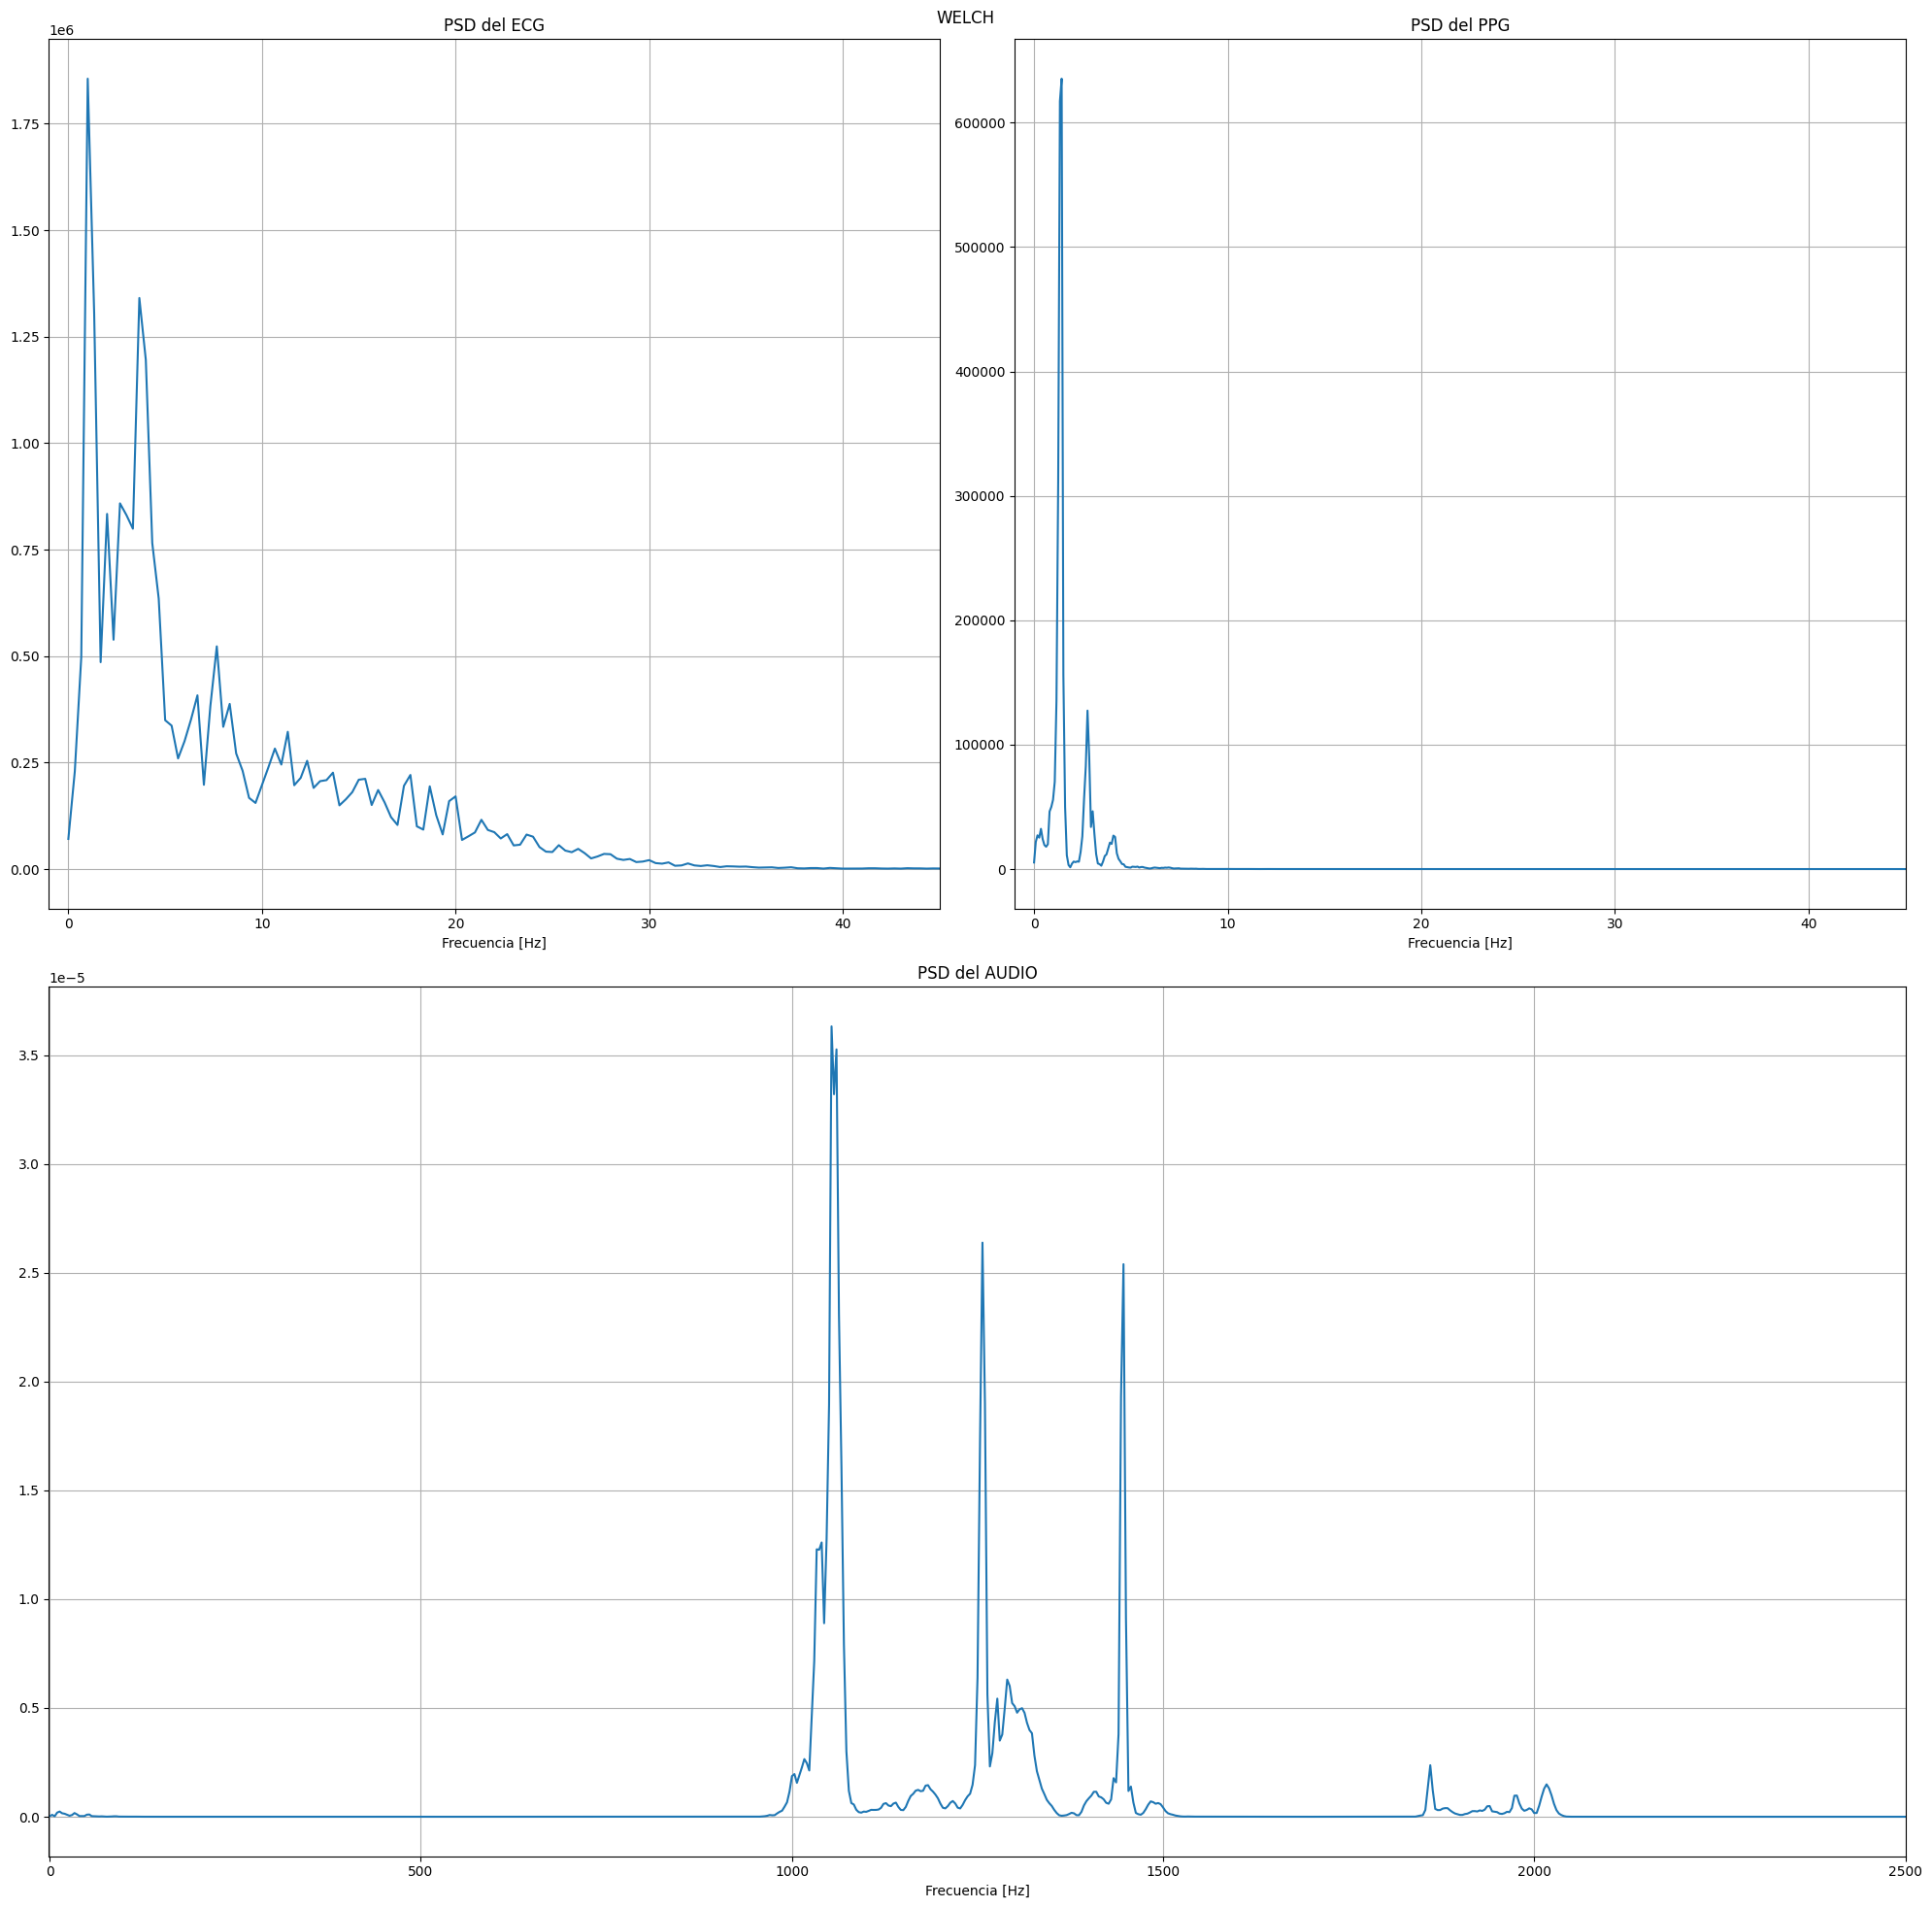

In [20]:
# WELCH

# ECG
cant_promedios_ecg = 10
nperseg = N_ECG // cant_promedios_ecg

f_ecg, Pxx_ecg = sig.welch(ecg_one_lead, fs = fs_ecg, window ='hamming', nperseg = nperseg, noverlap = 10)

# PPG
cant_promedios_ppg = 10
nperseg_ppg = N_PPG // cant_promedios_ppg

f_ppg, Pxx_ppg = sig.welch(ppg, fs = fs_ppg, window ='hamming', nperseg = nperseg_ppg)

# AUDIO LA CUCARACHA
cant_promedio_audio = 10 
nperseg_audio = N_audio // cant_promedio_audio

f_audio, Pxx_audio = sig.welch(wav_data, fs = fs_audio, window ='hamming', nperseg = nperseg_audio)

# Graficos
plt.figure(figsize = (20, 20))
plt.suptitle("WELCH")

plt.subplot(2,2,1)
plt.title("PSD del ECG")
plt.plot(f_ecg, Pxx_ecg)
plt.xlabel('Frecuencia [Hz]')
plt.xlim(-1, 45)
plt.grid()

plt.subplot(2,2,2)
plt.title("PSD del PPG")
plt.plot(f_ppg, Pxx_ppg)
plt.xlim(-1, 45)
plt.xlabel('Frecuencia [Hz]')
plt.grid()

plt.subplot(2,1,2)
plt.title("PSD del AUDIO")
plt.plot(f_audio, Pxx_audio)
plt.xlim(-1, 2500)
plt.xlabel('Frecuencia [Hz]')
plt.grid()

plt.tight_layout()
plt.show()

Posteriormente, se volvió a estimar la *PSD* utilizando el método de *Blackman-Tukey*, con el objetivo de comparar ambos estimadores espectrales y analizar sus diferencias en términos de resolución y estabilidad.

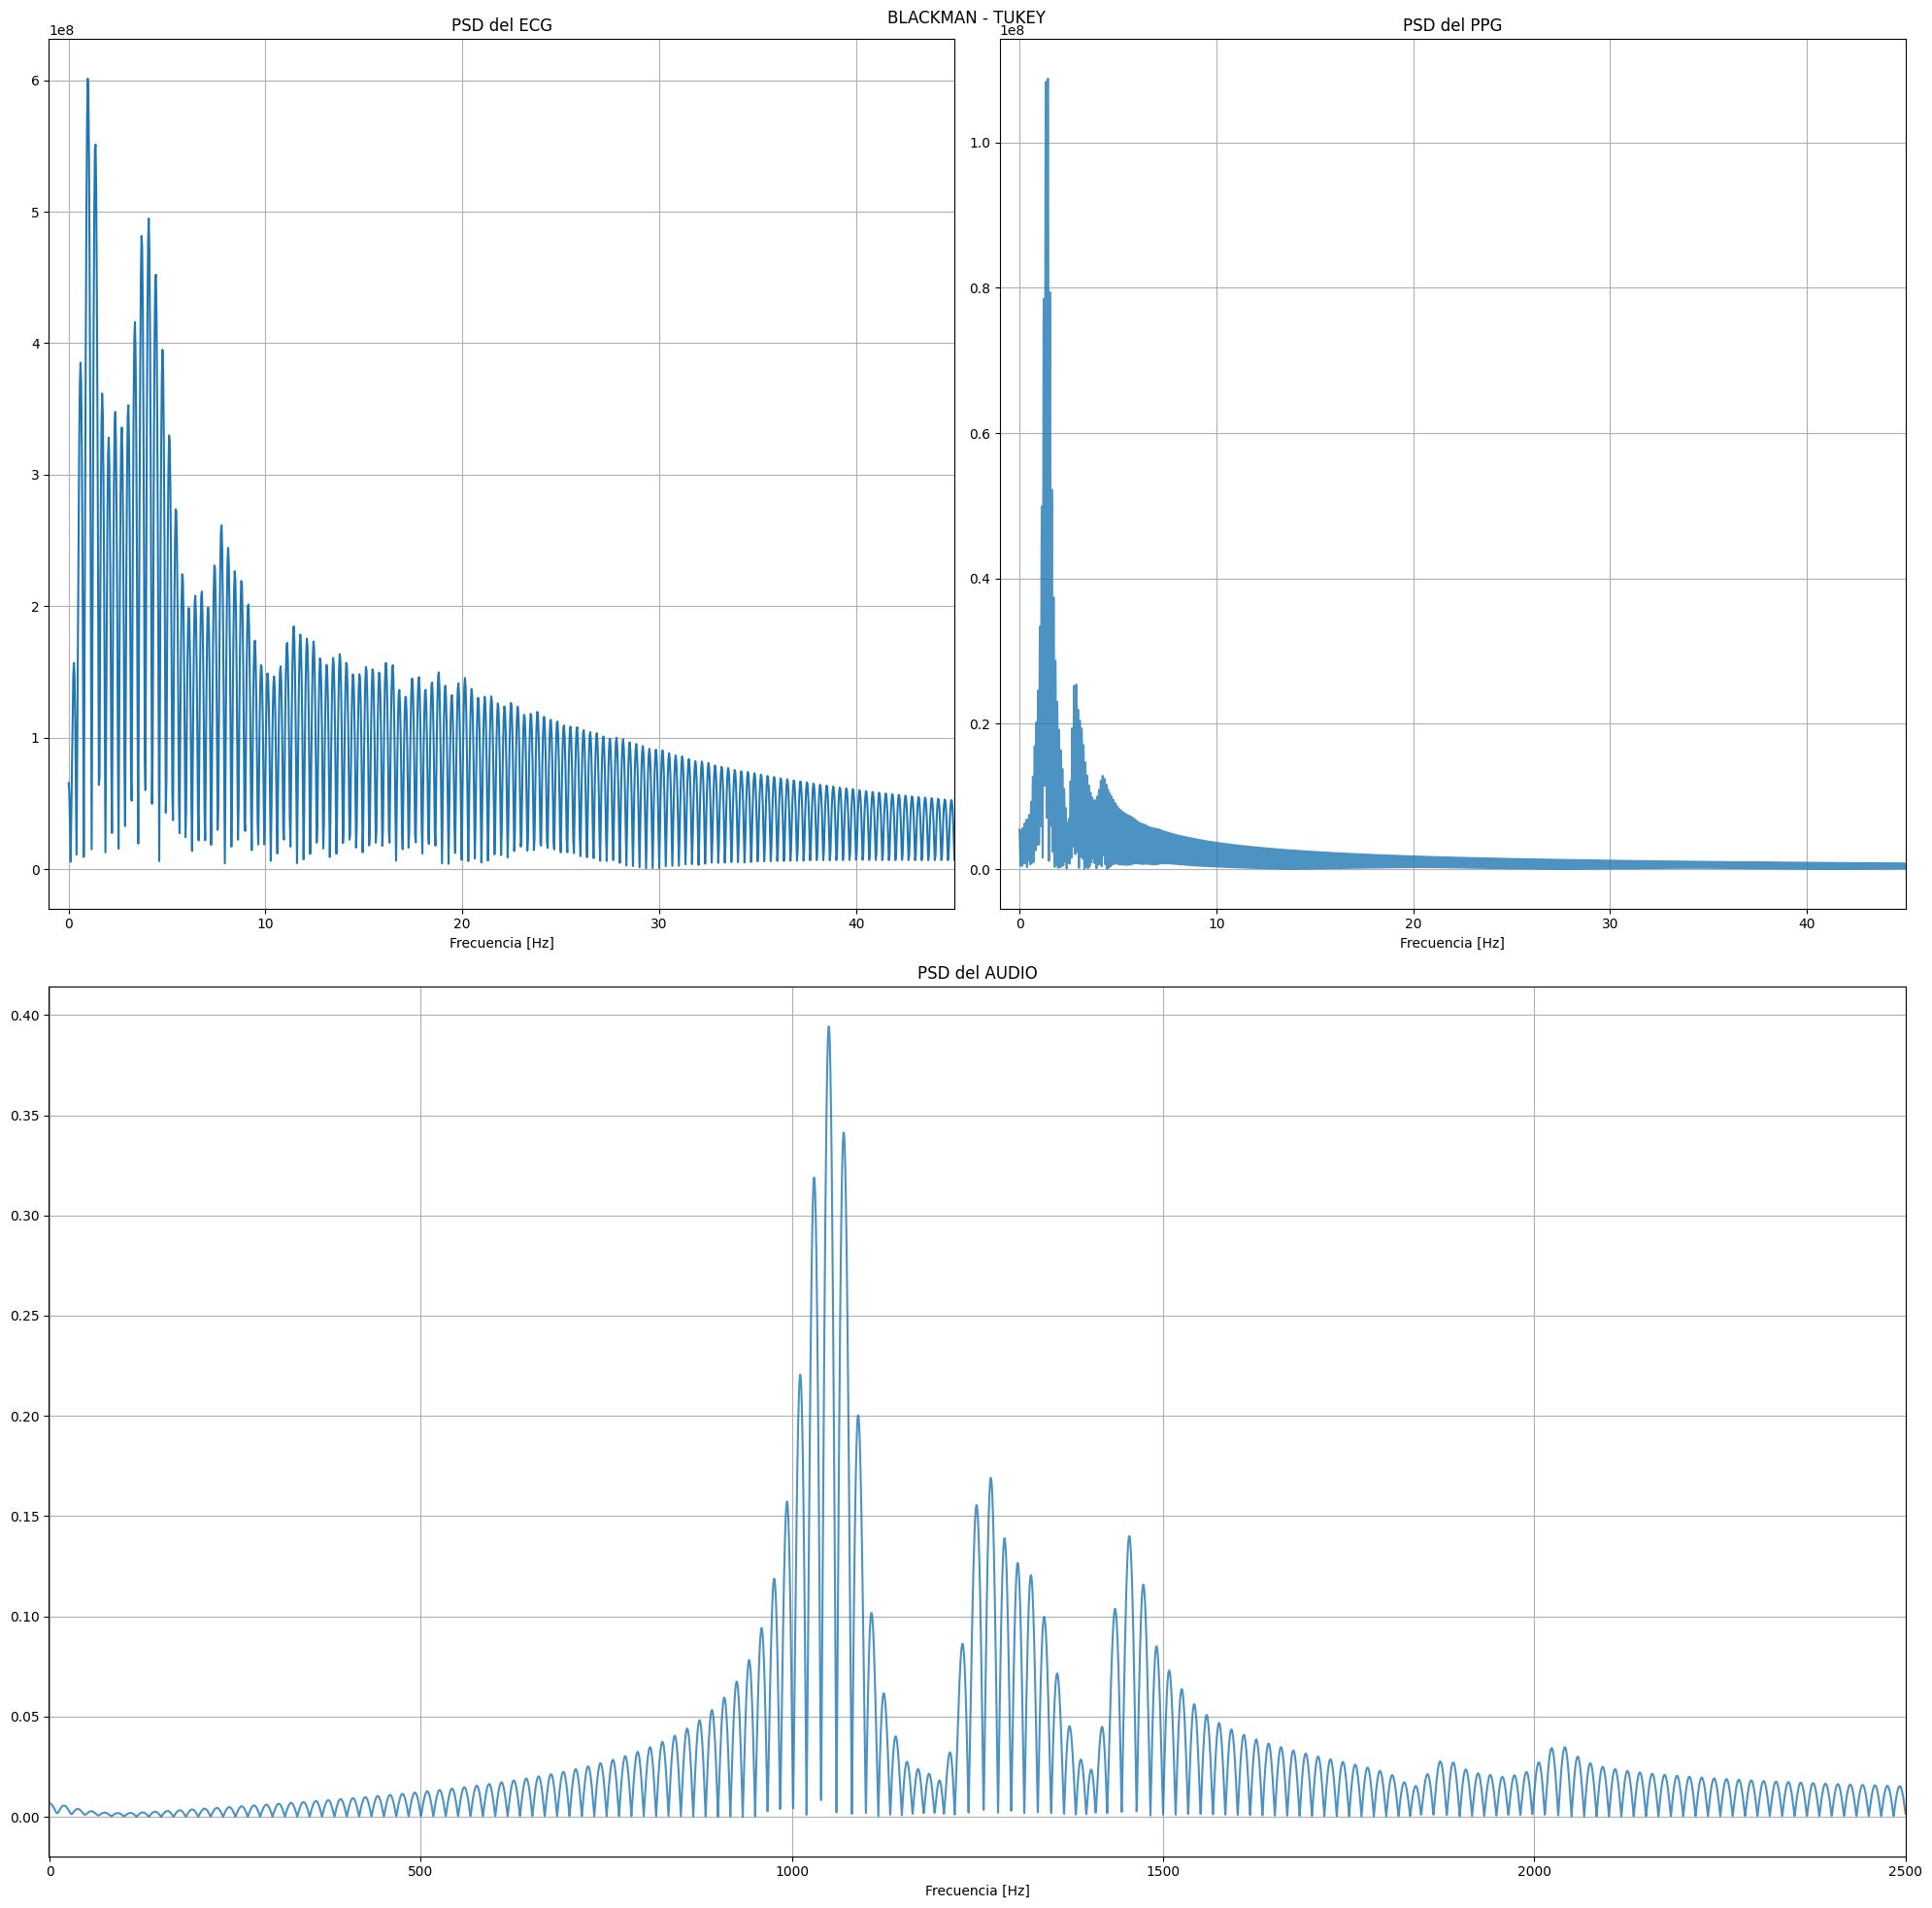

In [21]:
def blackman_tukey(x, fs, M=None):
    N = len(x)
    if M is None:
        M = N // 20
    M = min(M, N // 2 - 1)
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)                       # quito la continua

    r_full = np.correlate(x, x, mode='full') / N
    mid = len(r_full) // 2
    r = r_full[mid - (M - 1): mid + M]       # autocorrelacion simetrica, largo 2M-1

    window = sig.windows.blackman(len(r))
    r_windowed = r * window

    # CLAVE: reordeno para que el lag 0 quede en el indice 0 (fftshift),
    # asi la FFT no introduce fase espuria.
    Px = np.abs(np.fft.fft(np.fft.ifftshift(r_windowed), n=N))

    f = np.fft.fftfreq(N, d=1/fs)[:N // 2]
    Px = Px[:N // 2]
    return f, Px

# ECG
f_ecg_bt, Px_ecg_bt = blackman_tukey(ecg_one_lead, fs_ecg, M = N_ECG // 20)

# PPG
f_ppg_bt, Px_ppg_bt = blackman_tukey(ppg, fs_ppg, M=N_PPG // 20)

# AUDIO 
f_audio_bt, Px_audio_bt = blackman_tukey(wav_data, fs_audio, M=N_audio // 100)

# Graficos
plt.figure(figsize = (20, 20))
plt.suptitle("BLACKMAN - TUKEY")

plt.subplot(2,2,1)
plt.title("PSD del ECG")
plt.plot(f_ecg_bt, Px_ecg_bt)
plt.xlim(-1, 45)
plt.xlabel('Frecuencia [Hz]')
plt.grid()

plt.subplot(2,2,2)
plt.title("PSD del PPG")
plt.plot(f_ppg_bt, Px_ppg_bt, alpha=0.8)
plt.xlim(-1, 45) 
plt.xlabel('Frecuencia [Hz]')
plt.grid()

plt.subplot(2,1,2)
plt.title("PSD del AUDIO")
plt.plot(f_audio_bt, Px_audio_bt, alpha=0.8)
plt.xlim(-1, 2500)
plt.xlabel('Frecuencia [Hz]')
plt.grid()

plt.tight_layout()
plt.show()

A continuación, se calculó la varianza asociada a cada método de estimación para evaluar el comportamiento de ambos estimadores. 

In [22]:
# Analisis de la varianza 
var_ecg_W = (Pxx_ecg ** 2 / cant_promedios_ecg).mean()
var_ppg_W = (Pxx_ppg ** 2 / cant_promedios_ppg).mean()
var_audio_W = (Pxx_audio ** 2 / cant_promedio_audio).mean()

# Energia de la ventana Blackman de cada senal (Ew = sum(w^2))
Ew_ecg   = np.sum(sig.windows.blackman(2 * (N_ECG // 20) - 1) ** 2)
Ew_ppg   = np.sum(sig.windows.blackman(2 * (N_PPG // 20) - 1) ** 2)
Ew_audio = np.sum(sig.windows.blackman(2 * (N_audio // 100) - 1) ** 2)

# Varianza Blackman-Tukey:  Var[P(f)] ~ P(f)^2 * Ew / N
var_ecg_BT = (Px_ecg_bt ** 2 * Ew_ecg / N_ECG).mean()
var_ppg_BT = (Px_ppg_bt ** 2 * Ew_ppg / N_PPG).mean()
var_audio_BT = (Px_audio_bt ** 2 * Ew_audio / N_audio).mean()

# Presento los resultados en una tabla
from IPython.display import display, HTML

html = f"""
<div style="text-align:center;">

<h3>ANALISIS DE VARIANZA: Welch vs Blackman-Tukey</h3>

<table style="margin:auto; border-collapse:collapse;" border="1" cellpadding="8">
    <tr>
        <th>Señal</th>
        <th>Welch [Hz]</th>
        <th>Blackman-Tukey [Hz]</th>
    </tr>
    <tr>
        <td>ECG</td>
        <td>{var_ecg_W:.3e}</td>
        <td>{var_ecg_BT:.3e}</td>
    </tr>
    <tr>
        <td>PPG</td>
        <td>{var_ppg_W:.3e}</td>
        <td>{var_ppg_BT:.3e}</td>
    </tr>
    <tr>
        <td>Audio</td>
        <td>{var_audio_W:.3e}</td>
        <td>{var_audio_BT:.3e}</td>
    </tr>
</table>

</div>
"""

display(HTML(html))


Señal,Welch [Hz],Blackman-Tukey [Hz]
ECG,1.053e+09,5.149e+13
PPG,4.396e+07,4.349e+11
Audio,1.212e-13,1.964e-06


Finalmente, se estimó el ancho de banda de cada una de las señales analizadas a partir de las densidades espectrales de potencia obtenidas mediante ambos métodos. 

In [23]:
# Ancho de banda con Welch

# ECG
df_ecg = f_ecg[1] - f_ecg[0]
acum = np.cumsum(Pxx_ecg) * df_ecg
acum_norm = acum / acum[-1]

idx_inf_ecg = np.where(acum_norm >= 0.005)[0][0] # Límite inferior (0.5%)
idx_sup_ecg = np.where(acum_norm >= 0.995)[0][0] # Límite superior (99.5%)

f_inf_ecg = f_ecg[idx_inf_ecg]
f_sup_ecg = f_ecg[idx_sup_ecg]
BW_ecg = f_sup_ecg - f_inf_ecg

# PPG
df_ppg = f_ppg[1] - f_ppg[0]
acum = np.cumsum(Pxx_ppg) * df_ppg
acum_norm = acum / acum[-1]

idx_inf_ppg = np.where(acum_norm >= 0.005)[0][0] # Límite inferior (0.5%)
idx_sup_ppg = np.where(acum_norm >= 0.995)[0][0] # Límite superior (99.5%)

f_inf_ppg = f_ppg[idx_inf_ppg]
f_sup_ppg = f_ppg[idx_sup_ppg]
BW_ppg = f_sup_ppg - f_inf_ppg

# AUDIO LA CUCARACHA
df_audio = f_audio[1] - f_audio[0]
acum = np.cumsum(Pxx_audio) * df_audio
acum_norm = acum / acum[-1]

idx_inf_audio = np.where(acum_norm >= 0.005)[0][0]   # limite inferior (0.5%)
idx_sup_audio = np.where(acum_norm >= 0.995)[0][0]   # limite superior (99.5%)

f_inf_audio = f_audio[idx_inf_audio]
f_sup_audio = f_audio[idx_sup_audio]
BW_audio = f_sup_audio - f_inf_audio


# Ancho de banda con Blackman-Tukey

# ECG 
df = f_ecg_bt[1] - f_ecg_bt[0]
acum = np.cumsum(Px_ecg_bt) * df
acum_norm = acum / acum[-1]
idx = np.where(acum_norm >= 0.99)[0][0]
BW_ecg_bt = f_ecg_bt[idx]

# PPG
df = f_ppg_bt[1] - f_ppg_bt[0]
acum = np.cumsum(Px_ppg_bt) * df
acum_norm = acum / acum[-1]
idx = np.where(acum_norm >= 0.99)[0][0]
BW_ppg_bt = f_ppg_bt[idx]

# AUDIO LA CUCARACHA
df = f_audio_bt[1] - f_audio_bt[0]
acum = np.cumsum(Px_audio_bt) * df
acum_norm = acum / acum[-1]
idx_inf = np.where(acum_norm >= 0.005)[0][0]
idx_sup = np.where(acum_norm >= 0.995)[0][0]
BW_audio_bt = f_audio_bt[idx_sup] - f_audio_bt[idx_inf]


# Comparacion de anchos de banda 
from IPython.display import display, HTML

html = f"""
<div style="text-align:center;">

<h3>ANCHO DE BANDA: Welch vs Blackman-Tukey</h3>

<table style="margin:auto; border-collapse:collapse;" border="1" cellpadding="8">
    <tr>
        <th>Señal</th>
        <th>Welch [Hz]</th>
        <th>Blackman-Tukey [Hz]</th>
    </tr>
    <tr>
        <td>ECG</td>
        <td>{BW_ecg:.1f}</td>
        <td>{BW_ecg_bt:.1f}</td>
    </tr>
    <tr>
        <td>PPG</td>
        <td>{BW_ppg:.1f}</td>
        <td>{BW_ppg_bt:.1f}</td>
    </tr>
    <tr>
        <td>Audio</td>
        <td>{BW_audio:.1f}</td>
        <td>{BW_audio_bt:.1f}</td>
    </tr>
</table>

</div>
"""

display(HTML(html))

Señal,Welch [Hz],Blackman-Tukey [Hz]
ECG,34.7,481.6
PPG,6.7,190.8
Audio,1033.3,23230.7


# <u> **Conclusiones** <u>

A partir del procesamiento y análisis espectral de las tres señales proporcionadas (ECG, PPG y audio), se observó que las señales biológicas (*ECG* y *PPG*) concentran su energía principalmente en bajas frecuencias, mientras que la señal acústica (*audio de la cucaracha*) presenta un espectro mucho más ancho y con mayor contenido de componentes de alta frecuencia. 

En particular, el *ECG* analizado mediante el método de *Welch*, mostró una densidad espectral de potencia con la mayor parte de su energía concentrada por debajo de unos pocos *Hz*, lo cual resulta coherente con la naturaleza rítmica y lenta de la actividad cardiaca. De manera similar, la señal *PPG* presentó un comportamiento *pasa-bajos*, con energía dominante en frecuencias bajas asociadas a las variaciones pulsatiles de la señal. Por otra parte, la señal de audio analizada tanto con Welch como con *Blackman-Tukey*, mostró un ancho de banda considerablemente mayor, evidenciando la mayor complejidad espectral y variabilidad temporal propia de las señales acústicas. 

Los resultados obtenidos para el ancho de banda confirman esta diferencia: las señales biológicas poseen un ancho de banda reducido, mientras que la señal acústica presenta una extensión espectral mucho más amplia. Esto concuerda con lo esperado teóricamente, ya que las señales fisiológicas suelen variar lentamente en el tiempo, mientras que las señales de audio contienen múltiples componentes armónicas y transitorios de frecuencia más elevada. 

Además, la comparación entre los m+etodos de estimación espectral permitió observar diferencias importantes en cuanto a resolución y estabilidad de las estimaciones. El método de *Welch* produjo espectros más suaves y estables debido al promediado de segmentos, reduciendo significativamente la varianza del estimador. Sin embargo, esta reducción de varianza implica una pérdida parcial de resolución espectral debido al uso de segmentos más cortos y ventanas temporales. 

Por oto lado, el método de *Blackman-Tukey* permitió conservar un mayor detalle espectral en ciertas regiones de frecuencia, aunque presentando una mayor variabilidad en la estimación. El análisis de varianza realizado confirmó este compromiso clásico entre resolución y estabilidad: *Welch* presentó menores valores de varianza, mientras que *Blackman-Tukey* mostró fluctuaciones mayores en la *PSD* estimada. 

En conclusión, los resultados obtenidos concuerdan con lo desarrollado en la teoría: 

- Las señales biológicas son predominantes pasabajas, con energía concentrada en bajas frecuencias.
- La señal de audio posee un espectro más amplio y de mayor complejidad.
- El método de *Welch* resulta más robusto y estable frente a fluctuaciones espectrales.
- *Blackman-Tukey* permite obtener una mejor resolución frecuencial, aunque con mayor varianza en la estimación espectral.